In [1]:
from __future__ import annotations

import argparse
import json
import os
import pickle as pkl

import numpy as np
import pandas as pd
from sklearn.datasets import load_svmlight_file

import xgboost as xgb
from xgboost.testing.data import RelDataCV, simulate_clicks, sort_ltr_samples

In [4]:
def load_mslr_10k(data_path: str, cache_path: str) -> RelDataCV:
    """Load the MSLR10k dataset from data_path and cache a pickle object in cache_path.

    Returns
    -------

    A list of tuples [(X, y, qid), ...].

    """
    root_path = os.path.expanduser(data_path)
    cacheroot_path = os.path.expanduser(cache_path)
    cache_path = os.path.join(cacheroot_path, "MSLR_10K_LETOR.pkl")

    # Use only the Fold1 for demo:
    # Train,      Valid, Test
    # {S1,S2,S3}, S4,    S5
    fold = 1

    if not os.path.exists(cache_path):
        fold_path = os.path.join(root_path, f"Fold{fold}")
        train_path = os.path.join(fold_path, "train.txt")
        valid_path = os.path.join(fold_path, "vali.txt")
        test_path = os.path.join(fold_path, "test.txt")
        X_train, y_train, qid_train = load_svmlight_file(
            train_path, query_id=True, dtype=np.float32
        )
        y_train = y_train.astype(np.int32)
        qid_train = qid_train.astype(np.int32)

        X_valid, y_valid, qid_valid = load_svmlight_file(
            valid_path, query_id=True, dtype=np.float32
        )
        y_valid = y_valid.astype(np.int32)
        qid_valid = qid_valid.astype(np.int32)

        X_test, y_test, qid_test = load_svmlight_file(
            test_path, query_id=True, dtype=np.float32
        )
        y_test = y_test.astype(np.int32)
        qid_test = qid_test.astype(np.int32)

        data = RelDataCV(
            train=(X_train, y_train, qid_train),
            test=(X_test, y_test, qid_test),
            max_rel=4,
        )

        with open(cache_path, "wb") as fd:
            pkl.dump(data, fd)

    with open(cache_path, "rb") as fd:
        data = pkl.load(fd)

    return data

In [5]:
# data = load_mslr_10k("~/Data/MSLR-WEB10K/", "~/Data/MSLR-WEB10K/cache/")

In [6]:
# Sort data according to query index
X_train, y_train, qid_train = data.train
sorted_idx = np.argsort(qid_train)
X_train = X_train[sorted_idx]
y_train = y_train[sorted_idx]
qid_train = qid_train[sorted_idx]

X_test, y_test, qid_test = data.test
sorted_idx = np.argsort(qid_test)
X_test = X_test[sorted_idx]
y_test = y_test[sorted_idx]
qid_test = qid_test[sorted_idx]

In [7]:
ranker = xgb.XGBRanker(
    tree_method="hist",
    device="cuda",
    lambdarank_pair_method="topk",
    lambdarank_num_pair_per_sample=13,
    eval_metric=["ndcg@1", "ndcg@8"],
)
ranker.fit(
    X_train,
    y_train,
    qid=qid_train,
    eval_set=[(X_test, y_test)],
    eval_qid=[qid_test],
    verbose=True,
)

[0]	validation_0-ndcg@1:0.38133	validation_0-ndcg@8:0.40574
[1]	validation_0-ndcg@1:0.41174	validation_0-ndcg@8:0.42529
[2]	validation_0-ndcg@1:0.41992	validation_0-ndcg@8:0.43059
[3]	validation_0-ndcg@1:0.42747	validation_0-ndcg@8:0.43431
[4]	validation_0-ndcg@1:0.43188	validation_0-ndcg@8:0.43765
[5]	validation_0-ndcg@1:0.42815	validation_0-ndcg@8:0.44075
[6]	validation_0-ndcg@1:0.43857	validation_0-ndcg@8:0.44579
[7]	validation_0-ndcg@1:0.44384	validation_0-ndcg@8:0.44882
[8]	validation_0-ndcg@1:0.44585	validation_0-ndcg@8:0.45294
[9]	validation_0-ndcg@1:0.44823	validation_0-ndcg@8:0.45481
[10]	validation_0-ndcg@1:0.44728	validation_0-ndcg@8:0.45661
[11]	validation_0-ndcg@1:0.44942	validation_0-ndcg@8:0.46059
[12]	validation_0-ndcg@1:0.44975	validation_0-ndcg@8:0.46334
[13]	validation_0-ndcg@1:0.45712	validation_0-ndcg@8:0.46568
[14]	validation_0-ndcg@1:0.46139	validation_0-ndcg@8:0.46728
[15]	validation_0-ndcg@1:0.46204	validation_0-ndcg@8:0.46917
[16]	validation_0-ndcg@1:0.46504	v

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'rank:ndcg'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

/home/ubuntu/pyenv/py312/lib/python3.12/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


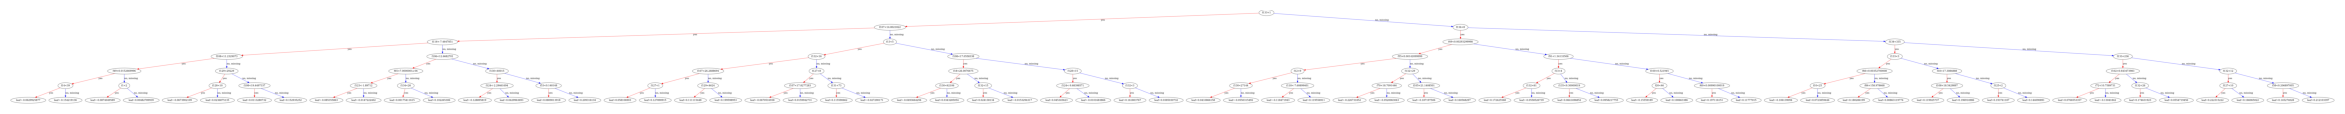

In [12]:
import matplotlib.pyplot as plt

xgb.plot_tree(ranker, num_trees=1)
fig = plt.gcf()
fig.set_size_inches(30, 30) # 把图调大一些，看得更清楚
plt.show()